<div style="background: linear-gradient(135deg, #4b2e83, #8e44ad); padding: 28px 32px; border-radius: 10px; color: white; margin-bottom: 4px;">
<h2 style="margin:0; font-weight:600;">Carnet 03 — Analyse entropique des séries simulées</h2>
<p style="margin:8px 0 0; opacity:0.92; font-size: 15px;">Comparer les régimes indépendant et auto-organisé par leurs signatures informationnelles</p>
</div>

### Rappel de la question

Le carnet 02 a produit deux séries de 2000 et 3000 jours, générées par le même
code (`evolution.simuler`) mais avec une différence physique précise :
`independant` tire chaque jour de façon indépendante autour d'une demande fixe,
tandis que `auto_organise` fait croître lentement la demande et met à niveau le
réseau en réponse aux marges et aux blackouts. Ce carnet pose une seule
question à la fois : **une mesure d'information donnée, appliquée seulement à
la série de nombres résultante (sans savoir dans quel mode elle a été
produite), peut-elle dire laquelle est laquelle ?**

On teste deux mesures du fil B, qui ne regardent pas les données de la même
façon :
- l'**entropie de permutation** (`permutation()`) — sensible seulement à
  l'ordre relatif des valeurs dans une petite fenêtre ;
- l'**entropie multiéchelle** (`multiechelle()`, fondée sur la SampEn) —
  sensible à la régularité des *valeurs* elles-mêmes, à plusieurs résolutions
  temporelles.


In [1]:
import numpy as np

from cascade_entropy import figures
from cascade_entropy.chemins import DOSSIER_DATA
from cascade_entropy.entropie import permutation, multiechelle

figures.appliquer_style()

# DOSSIER_DATA pointe toujours vers <racine_du_depot>/data, peu importe le
# répertoire de travail du noyau Jupyter (notebooks/ ou la racine).
dossier = DOSSIER_DATA
series = {
    "independant": dict(np.load(dossier / "evolution_independant.npz")),
    "auto_organise": dict(np.load(dossier / "evolution_auto_organise.npz")),
}

for mode, s in series.items():
    print(f"{mode:15s} : {s['jour'].size} jours, clés = {list(s.keys())}")


independant     : 2000 jours, clés = ['jour', 'delestage_total', 'taux_maximal', 'nombre_effectif', 'n_lignes_en_service']
auto_organise   : 3000 jours, clés = ['jour', 'delestage_total', 'taux_maximal', 'nombre_effectif', 'n_lignes_en_service', 'capacite_totale_generateurs', 'marge_moyenne', 'n_mises_a_niveau', 'n_lignes_renforcees']


<div style="background: linear-gradient(135deg, #1f4e79, #2e7d5b); padding: 28px 32px; border-radius: 10px; color: white; margin-bottom: 4px;">
<h2 style="margin:0; font-weight:600;">Étape 01 — Le piège des égalités</h2>
<p style="margin:8px 0 0; opacity:0.92; font-size: 15px;">Avant d'appliquer <code>permutation()</code>, on vérifie si une série contient trop de valeurs exactement égales pour que l'ordre relatif ait un sens.</p>
</div>

`permutation()` repose sur `np.argsort` pour trouver l'ordre relatif des
valeurs dans chaque fenêtre. Cet ordre n'existe que si les valeurs sont
distinctes : si deux valeurs d'une même fenêtre sont exactement égales,
`argsort` doit quand même leur assigner un rang, de façon arbitraire (ici,
stable — déterminée par la position). Ce rang arbitraire n'est pas une vraie
propriété de la dynamique : c'est un artefact.

`delestage_total` vaut exactement zéro la plupart des jours sans blackout —
on vérifie directement combien, et à quel point ça contamine les fenêtres de
3 jours consécutifs utilisées par `permutation()`.

In [2]:
def diagnostic_egalites(serie, dimension=3, delai=1):
    frac_zero = float(np.mean(np.isclose(serie, 0.0, atol=1e-9)))
    distinctes = np.unique(serie).size
    n_fenetres = serie.size - (dimension - 1) * delai
    fenetres = np.array([serie[i:i + dimension * delai:delai]
                         for i in range(n_fenetres)])
    frac_egalite = float(np.mean([np.unique(f).size < dimension for f in fenetres]))
    return frac_zero, distinctes, frac_egalite

variables = ["delestage_total", "taux_maximal", "nombre_effectif"]
print(f"{'variable':20s} {'mode':15s} {'frac. zéro':>11s} {'distinctes':>11s} "
      f"{'fenêtres (dim=3) avec égalité':>30s}")
for var in variables:
    for mode, s in series.items():
        fz, nd, fe = diagnostic_egalites(s[var])
        print(f"{var:20s} {mode:15s} {fz:10.1%} {nd:11d} {fe:29.1%}")
    print()


variable             mode             frac. zéro  distinctes  fenêtres (dim=3) avec égalité
delestage_total      independant          17.9%        1643                          7.7%
delestage_total      auto_organise        60.9%        1173                         65.5%

taux_maximal         independant           0.0%         764                          3.6%
taux_maximal         auto_organise         0.0%        2988                          0.1%

nombre_effectif      independant           0.0%        2000                          0.0%
nombre_effectif      auto_organise         0.0%        3000                          0.0%



**Lecture.** `taux_maximal` et `nombre_effectif` n'ont essentiellement
aucune égalité, dans aucun mode : ce sont des candidats sûrs pour
`permutation()`. `delestage_total`, en revanche, est dominé par des zéros
exacts — 18 % des jours en mode `independant`, et **61 %** en mode
`auto_organise` (le réseau, en moyenne, a plus de marge dans ce mode, donc
moins souvent de blackout). La conséquence directe : 65 % des fenêtres de
3 jours consécutifs contiennent une égalité en mode `auto_organise`, contre
8 % en mode `independant` — presque exactement ce que prédirait le hasard à
partir de la seule fraction de zéros, donc ce n'est même pas un signe de
structure temporelle supplémentaire. On garde `delestage_total` à part : toute
différence d'entropie de permutation qu'on y observerait serait confondue
avec ce taux de zéros, pas avec une vraie différence de dynamique.

<div style="background: linear-gradient(135deg, #1f4e79, #c55a11); padding: 28px 32px; border-radius: 10px; color: white; margin-bottom: 4px;">
<h2 style="margin:0; font-weight:600;">Étape 02 — Entropie de permutation : l'ordre à court terme</h2>
<p style="margin:8px 0 0; opacity:0.92; font-size: 15px;">On applique <code>permutation()</code> aux deux séries propres, à deux dimensions d'immersion, puis on balaie le délai pour voir si un effet apparaît à plus longue portée.</p>
</div>

In [3]:
resultats_permutation = {}
for dimension in (3, 4):
    for var in ("taux_maximal", "nombre_effectif", "delestage_total"):
        for mode, s in series.items():
            h = permutation(s[var], dimension=dimension, delai=1, normaliser=True)
            resultats_permutation[(var, dimension, mode)] = h

print(f"{'variable':20s} {'dim':>4s} {'independant':>12s} {'auto_organise':>14s}")
for var in ("taux_maximal", "nombre_effectif", "delestage_total"):
    for dimension in (3, 4):
        a = resultats_permutation[(var, dimension, "independant")]
        b = resultats_permutation[(var, dimension, "auto_organise")]
        print(f"{var:20s} {dimension:4d} {a:12.4f} {b:14.4f}")


variable              dim  independant  auto_organise
taux_maximal            3       0.9999         0.9999
taux_maximal            4       0.9994         0.9991
nombre_effectif         3       0.9996         0.9997
nombre_effectif         4       0.9985         0.9988
delestage_total         3       0.9976         0.8349
delestage_total         4       0.9944         0.7853


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/04_entropie/permutation_taux_maximal.png')

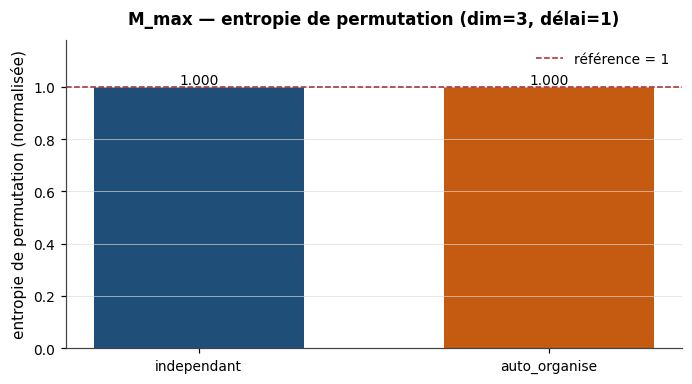

In [4]:
fig = figures.barres_comparatives(
    {"independant": resultats_permutation[("taux_maximal", 3, "independant")],
     "auto_organise": resultats_permutation[("taux_maximal", 3, "auto_organise")]},
    ylabel="entropie de permutation (normalisée)", reference=1.0,
    titre="M_max — entropie de permutation (dim=3, délai=1)",
)
figures.sauvegarder(fig, "permutation_taux_maximal", sous_dossier="04_entropie")


WindowsPath('c:/Users/alexb/Documents/Projets/cascade-entropy/figures/04_entropie/permutation_nombre_effectif.png')

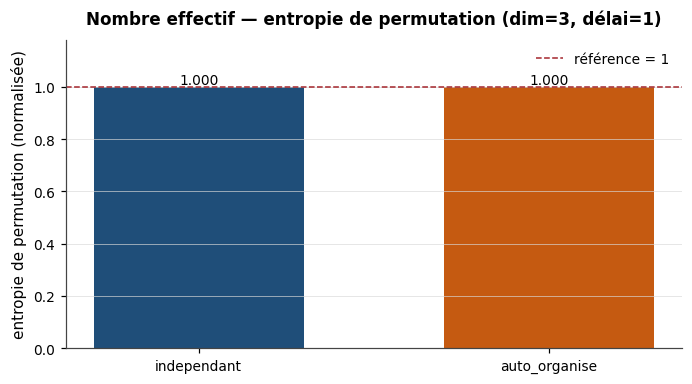

In [5]:
fig = figures.barres_comparatives(
    {"independant": resultats_permutation[("nombre_effectif", 3, "independant")],
     "auto_organise": resultats_permutation[("nombre_effectif", 3, "auto_organise")]},
    ylabel="entropie de permutation (normalisée)", reference=1.0,
    titre="Nombre effectif — entropie de permutation (dim=3, délai=1)",
)
figures.sauvegarder(fig, "permutation_nombre_effectif", sous_dossier="04_entropie")


Les deux mesures sont quasiment au maximum théorique (1,0 = les 6 motifs
d'ordre également probables, comme un bruit blanc) **dans les deux modes**. À
l'échelle de 3-4 jours consécutifs, l'ordre relatif ressemble à du pur hasard,
qu'on soit en train de tirer des jours indépendants ou de faire évoluer le
réseau lentement.

On pousse la vérification en espaçant les jours comparés, pour voir si la
dérive lente de l'auto-organisation apparaît à plus grande échelle plutôt
qu'entre jours voisins.

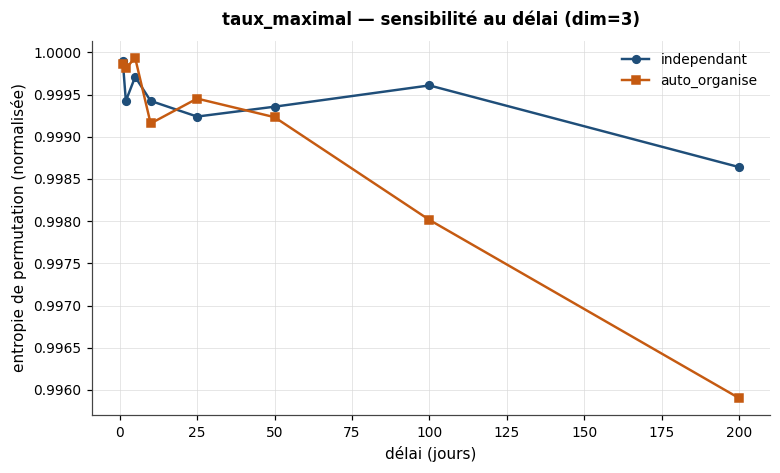

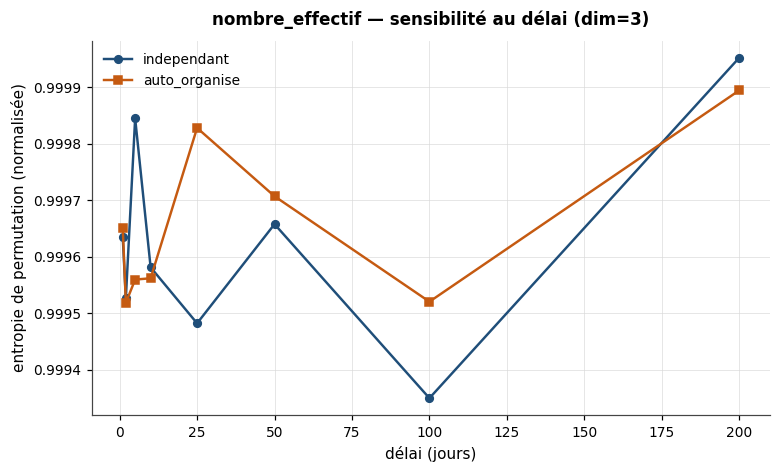

In [6]:
delais = [1, 2, 5, 10, 25, 50, 100, 200]
balayage_delai = {var: {mode: [] for mode in series} for var in
                   ("taux_maximal", "nombre_effectif")}

for var in balayage_delai:
    for mode, s in series.items():
        for delai in delais:
            balayage_delai[var][mode].append(
                permutation(s[var], dimension=3, delai=delai, normaliser=True)
            )

for var, courbes in balayage_delai.items():
    fig = figures.courbes_parametriques(
        delais, {mode: np.array(v) for mode, v in courbes.items()},
        xlabel="délai (jours)", ylabel="entropie de permutation (normalisée)",
        titre=f"{var} — sensibilité au délai (dim=3)",
    )
    figures.sauvegarder(fig, f"permutation_delai_{var}", sous_dossier="04_entropie")


**Interprétation.** Même en espaçant la comparaison jusqu'à 200 jours,
l'écart reste minuscule (moins de 0,004 sur une échelle de 0 à 1). L'entropie
de permutation **ne distingue pas** les deux modes sur ces variables, à
aucune des échelles testées.

Ce n'est pas que le code ne fonctionne pas : c'est que le bruit journalier
(`g = 0,9`, qui fait fluctuer la demande de jour en jour) est énorme comparé
à la dérive lente de l'auto-organisation (1,8 %/an, des mises à niveau
occasionnelles). L'entropie de permutation ne regarde que l'**ordre** entre
quelques jours voisins — elle n'a structurellement aucune chance de détecter
une tendance qui se développe sur des centaines de jours, parce qu'à cette
échelle, le bruit domine complètement le signal. C'est un résultat négatif,
mais clair et expliqué — pas un échec de la mesure, une réponse à la question
posée : *pas à cette échelle, avec cette mesure*.

<div style="background: linear-gradient(135deg, #2e7d5b, #4b2e83); padding: 28px 32px; border-radius: 10px; color: white; margin-bottom: 4px;">
<h2 style="margin:0; font-weight:600;">Étape 03 — Entropie multiéchelle : la régularité des valeurs</h2>
<p style="margin:8px 0 0; opacity:0.92; font-size: 15px;">On change de mesure : <code>multiechelle()</code> (fondée sur la SampEn) est sensible aux valeurs elles-mêmes, pas seulement à leur ordre.</p>
</div>

La SampEn compare des motifs de valeurs *proches en amplitude* (à une
tolérance `r × écart-type` près), pas seulement ordonnés pareillement. Une
série non stationnaire — dont la distribution change avec le temps, comme
`auto_organise`, où la demande et la capacité croissent — a structurellement
plus de mal à produire des motifs qui se répètent que des jours tirés autour
d'une moyenne fixe. La multiéchelle refait ce calcul après avoir moyenné la
série par blocs de taille croissante (`granulariser`), pour voir comment
cette régularité évolue selon l'échelle d'observation.

In [7]:
resultats_mse = {}
for var in ("taux_maximal", "nombre_effectif"):
    resultats_mse[var] = {}
    for mode, s in series.items():
        echelles, valeurs = multiechelle(s[var], echelles=20, m=2, r=0.15)
        resultats_mse[var][mode] = (echelles, valeurs)

for var, par_mode in resultats_mse.items():
    print(f"=== {var} ===")
    for mode, (echelles, valeurs) in par_mode.items():
        print(f"  {mode:15s}  échelle 1 : {valeurs[0]:.3f}   "
              f"échelle {int(echelles[-1])} : {valeurs[-1]:.3f}")


=== taux_maximal ===
  independant      échelle 1 : 0.659   échelle 20 : 0.990
  auto_organise    échelle 1 : 2.164   échelle 20 : 1.115
=== nombre_effectif ===
  independant      échelle 1 : 2.436   échelle 20 : 1.009
  auto_organise    échelle 1 : 2.412   échelle 20 : 1.174


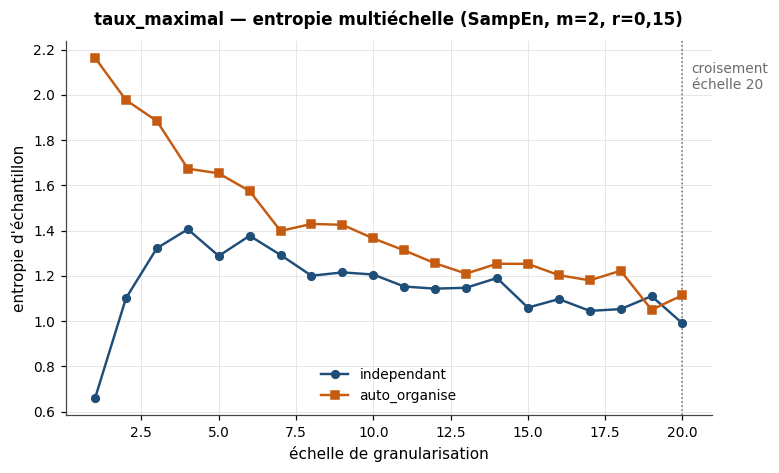

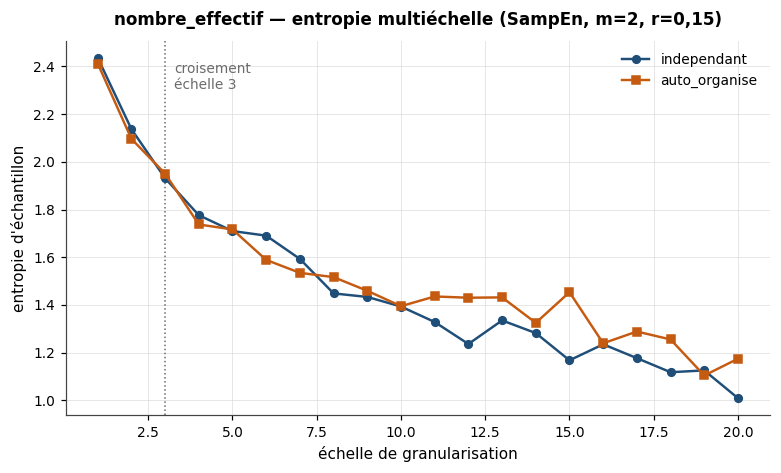

In [8]:
for var, par_mode in resultats_mse.items():
    echelles = par_mode["independant"][0]  # même grille pour les deux modes
    courbes = {mode: v for mode, (_, v) in par_mode.items()}
    fig = figures.courbes_multiechelle(
        echelles, courbes,
        titre=f"{var} — entropie multiéchelle (SampEn, m=2, r=0,15)",
    )
    figures.sauvegarder(fig, f"multiechelle_{var}", sous_dossier="04_entropie")


**Interprétation.** Ici, contrairement à `permutation()`, on voit une
différence nette — et dans le sens inverse de ce qu'on pourrait deviner
spontanément. À l'échelle 1 (la série brute, jour par jour), `auto_organise`
a une SampEn **beaucoup plus haute** que `independant` : la série brute y est
plus irrégulière, pas plus régulière. Ça fait sens : `independant` tire
chaque jour autour d'une distribution fixe — statistiquement, ça ressemble à
du bruit blanc stationnaire, et la SampEn d'un bruit blanc converge vers une
valeur de référence assez basse et stable. `auto_organise`, en revanche, n'a
pas une distribution fixe : la demande croît et la capacité change par sauts,
donc la série entière dérive — ce qui rend beaucoup plus difficile de
retrouver un motif qui se répète à l'identique, même à tolérance `r × écart-
type` près.

Puis, en lissant progressivement (grandes échelles), les deux courbes se
rapprochent : moyenner sur des blocs de plus en plus larges efface le bruit
journalier et révèle une structure plus lente et plus comparable entre les
deux modes.

**C'est le résultat complémentaire à celui de l'étape 02** : l'entropie de
permutation échoue à distinguer les modes parce qu'elle ignore l'amplitude et
ne regarde que l'ordre local ; l'entropie multiéchelle réussit précisément
parce qu'elle regarde l'amplitude et sa régularité statistique, qui porte la
signature de la non-stationnarité de `auto_organise` — visible dès l'échelle
la plus fine, et qui s'atténue quand on lisse.

<div style="background: linear-gradient(135deg, #4b2e83, #1f4e79); padding: 28px 32px; border-radius: 10px; color: white; margin-bottom: 4px;">
<h2 style="margin:0; font-weight:600;">Bilan</h2>
<p style="margin:8px 0 0; opacity:0.92; font-size: 15px;">Deux mesures, deux réponses différentes à la même question — et pourquoi, précisément, elles diffèrent.</p>
</div>

| mesure | distingue les modes ? | pourquoi |
|---|---|---|
| entropie de permutation (`taux_maximal`, `nombre_effectif`) | non, à aucune échelle testée (délai 1 à 200) | ne regarde que l'ordre local ; le bruit journalier (g=0,9) domine la dérive lente |
| entropie de permutation (`delestage_total`) | écart observé, mais **confondu** | 61 % de zéros exacts en auto_organise contre 18 % en independant — artefact de bris d'égalité, pas de dynamique |
| entropie multiéchelle / SampEn (`taux_maximal`, `nombre_effectif`) | **oui, nettement, aux échelles fines** | sensible à l'amplitude ; capte la non-stationnarité du mode auto_organise (demande et capacité qui dérivent) |

Les deux modes existaient précisément pour répondre à cette question, et on y
répond maintenant avec des résultats positifs *et* négatifs expliqués — ce
qui est plus solide qu'un seul résultat positif qu'on n'aurait pas su
expliquer.

**Pistes pour la suite**, non traitées ici : l'entropie de dispersion (citée
dans *Others 1*, qui symbolise par classes plutôt que par ordre strict,
contournerait nativement le problème des égalités sur `delestage_total`) ;
une analyse binaire (jour de blackout oui/non) combinée à une analyse
conditionnelle de la magnitude ; l'extension IEEE-118 et la validation croisée
avec `pandapower`, déjà identifiées et mises en attente.